# センサーデータのクレンジングと特徴量エンジニアリング
このノートブックでは、製造業などでよく見られる「汚いセンサーデータ」を擬似的に作成し、Pandasの**メソッドチェーン**を使って直感的にデータをクレンジング・加工する方法を学びます。

## 1. ライブラリのインポートとダミーデータの作成
まずは必要なライブラリをインポートし、ノイズや欠損が含まれた「汚いデータ（raw_temp）」を作成します。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("1. 汚いダミーデータの作成中...")
np.random.seed(42)
time_range = pd.date_range(start="2026-06-01 09:00:00", end="2026-06-01 09:10:00", freq="1s")
n_samples = len(time_range)

# 基本となるきれいな信号（温度変化のトレンド）
base_signal = 20.0 + np.sin(np.linspace(0, 3 * np.pi, n_samples)) * 5

# 激しい測定ノイズを付与
noise = np.random.normal(0, 0.8, n_samples)
dirty_temp = base_signal + noise

# 意図的に「通信不良によるデータ欠損(NaN)」を作る
nan_mask = np.random.rand(n_samples) < 0.15  # 15%の確率で欠損
dirty_temp[nan_mask] = np.nan

# 意図的に「異常な突発スパイク（ノイズ）」を入れる（例：センサーの一瞬の誤作動）
spike_indices = np.random.choice(n_samples, size=5, replace=False)
dirty_temp[spike_indices] = dirty_temp[spike_indices] + np.random.choice([8.0, -8.0], size=5)

# DataFrame化
df = pd.DataFrame({"raw_temp": dirty_temp}, index=time_range)
df.head()


1. 汚いダミーデータの作成中...


,raw_temp
2026-06-01 09:00:00,20.397371
2026-06-01 09:00:01,19.967925
2026-06-01 09:00:02,20.675205
2026-06-01 09:00:03,21.453956
2026-06-01 09:00:04,20.126630


## 2. メソッドチェーンによるデータクレンジング
ここが今回のメインポイントです！
先ほどのデータを加工する際、1行ずつ処理を羅列するのではなく、**メソッドチェーン**（`.`で処理を繋げていく書き方）を使うことで、データが上から下へとパイプラインのように流れていく様子を表現できます。

処理の流れ：
1. **リサンプル (`resample.mean`)**: 5秒間隔のデータに集約し、細かいノイズを抑えます。
2. **欠損値補間 (`interpolate`)**: 途切れたデータを線で結んで滑らかにします。
3. **移動平均 (`rolling.mean`)**: 30秒分（6行分）のデータを平均して、トレンドを抽出します。
4. **移動標準偏差 (`rolling.std`)**: データの「ばらつき」を計算し、異常検知などに使える特徴量を作ります。


In [2]:
print("2. クレンジング処理（リサンプル ＆ 補間）を開始...")

# メソッドチェーンを使って、一連の処理をパイプラインのように記述します
df_cleaned = (
    df
    .resample("5s").mean() # 1. 5秒間隔に集約
    .assign(
        # 2. 欠損値を線形補間
        cleaned_temp=lambda x: x["raw_temp"].interpolate(method="linear"),
        # 3. 30秒窓（6行）の移動平均で平滑化
        rolling_mean=lambda x: x["cleaned_temp"].rolling(window=6, min_periods=1).mean(),
        # 4. 30秒窓の移動標準偏差（ばらつき具合）
        rolling_std=lambda x: x["cleaned_temp"].rolling(window=6, min_periods=1).std()
    )
)

df_cleaned.head(10)


2. クレンジング処理（リサンプル ＆ 補間）を開始...


,raw_temp,cleaned_temp,rolling_mean,rolling_std
2026-06-01 09:00:00,20.524217,20.524217,20.524217,NaN
2026-06-01 09:00:05,20.898232,20.898232,20.711225,0.264468
2026-06-01 09:00:10,20.244614,20.244614,20.555688,0.327943
2026-06-01 09:00:15,20.824264,20.824264,20.622832,0.299551
2026-06-01 09:00:20,21.587395,21.587395,20.815744,0.503363
2026-06-01 09:00:25,21.807991,21.807991,20.981119,0.605634
2026-06-01 09:00:30,21.939227,21.939227,21.216954,0.664750
2026-06-01 09:00:35,22.087961,22.087961,21.415242,0.725345
2026-06-01 09:00:40,22.705172,22.705172,21.825335,0.618889
2026-06-01 09:00:45,23.117387,23.117387,22.207522,0.584118


## 3. 結果の可視化
加工したデータをグラフに描画して、処理の効果を確認します。
上段のグラフではノイズだらけの生データが滑らかになっている様子が、下段のグラフではデータのばらつき具合の推移が確認できます。


3. 結果の可視化グラフを作成中...


🎉 処理完了！グラフを 'sensor_cleaning_result.png' に保存しました。


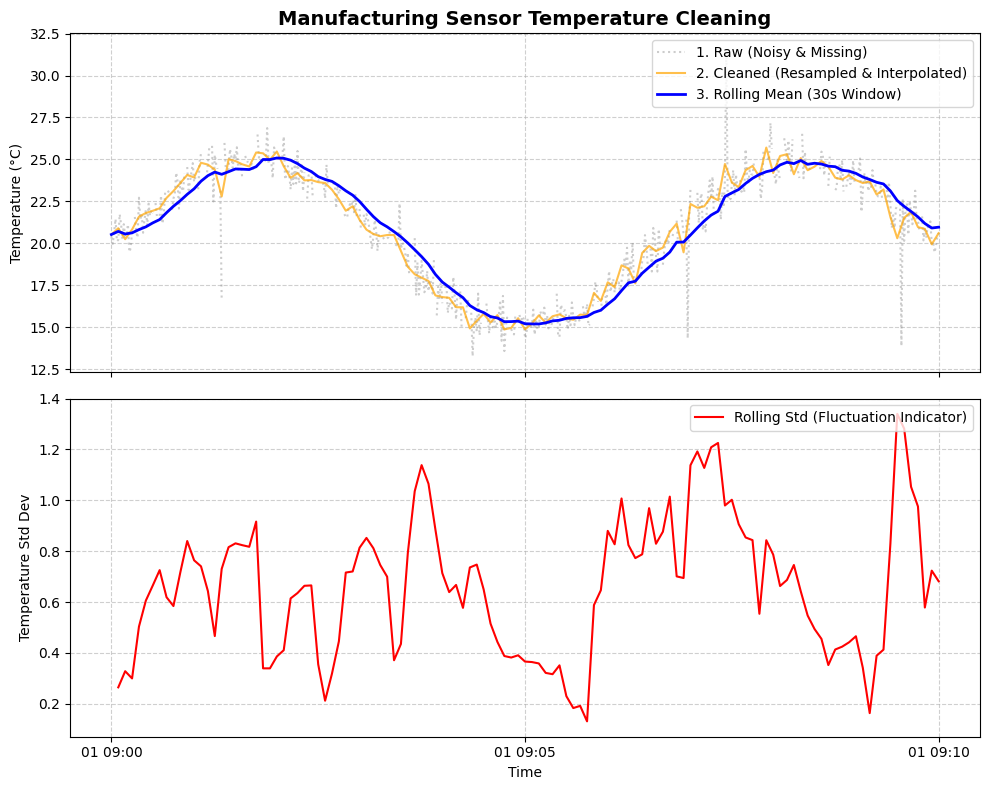

In [3]:
print("3. 結果の可視化グラフを作成中...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 上のグラフ: 生データとクレンジング後データの比較
ax1.plot(df.index, df["raw_temp"], label="1. Raw (Noisy & Missing)", color="gray", alpha=0.4, linestyle=":")
ax1.plot(df_cleaned.index, df_cleaned["cleaned_temp"], label="2. Cleaned (Resampled & Interpolated)", color="orange", alpha=0.7)
ax1.plot(df_cleaned.index, df_cleaned["rolling_mean"], label="3. Rolling Mean (30s Window)", color="blue", linewidth=2)
ax1.set_title("Manufacturing Sensor Temperature Cleaning", fontsize=14, fontweight="bold")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(loc="upper right")
ax1.grid(True, linestyle="--", alpha=0.6)

# 下のグラフ: ばらつき（移動標準偏差）の推移
ax2.plot(df_cleaned.index, df_cleaned["rolling_std"], label="Rolling Std (Fluctuation Indicator)", color="red", linewidth=1.5)
ax2.set_ylabel("Temperature Std Dev")
ax2.set_xlabel("Time")
ax2.legend(loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

# 結果を画像として保存
output_img = "sensor_cleaning_result.png"
plt.savefig(output_img, dpi=150)
print(f"🎉 処理完了！グラフを '{output_img}' に保存しました。")
plt.show()
